### Creating data to view and fit

In [2]:
from  sklearn.datasets import make_circles

# Make 1000 examples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

In [3]:
# Check out features
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [4]:
# Check the labels
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0], dtype=int64)

Visualizing our created data

In [5]:
import pandas as pd
circles = pd.DataFrame({"X0":X[:, 0], "X1":X[:, 1], "label":y})
circles

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


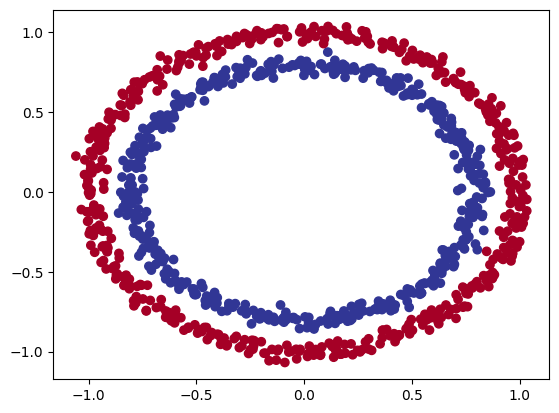

In [6]:
# Visuallize with a plot
import matplotlib.pyplot as plt 
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

### Input and output shapes

In [7]:
# Check the shapes of our features and labels
X.shape, y.shape

((1000, 2), (1000,))

In [8]:
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0], dtype=int64)

In [9]:
# how many samples we're working 
len(X), len(y)

(1000, 1000)

In [10]:
# View the first example of features and labels
X[5], y[5]

(array([-0.47964637,  0.67643477]), 1)

### Steps in modelling

In [11]:
import tensorflow as tf

# Set the random seed
tf.random.set_seed(42)

# 1. Create the model using the Sequential API
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["accuracy"])

# 3. Fit the model 
model_1.fit(X, y, epochs=5)



Epoch 1/5


32/32 [==============================] - 1s 2ms/step - loss: 4.9846 - accuracy: 0.5000
Epoch 2/5
32/32 [==============================] - 0s 1ms/step - loss: 4.7945 - accuracy: 0.5350
Epoch 3/5
32/32 [==============================] - 0s 1ms/step - loss: 4.7553 - accuracy: 0.5310
Epoch 4/5
32/32 [==============================] - 0s 1ms/step - loss: 4.6887 - accuracy: 0.5340
Epoch 5/5
32/32 [==============================] - 0s 1ms/step - loss: 4.6282 - accuracy: 0.5310


In [12]:
# Let's try and improve our model by training for longer
model_1.fit(X, y, epochs=200, verbose=0)

In [13]:
# Evaluation
model_1.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.6935 - accuracy: 0.5000


[0.6934831142425537, 0.5]

In [14]:
# let's add extra layer

# Set the random seed
tf.random.set_seed(42)

# 1. Create a model, this time with 2 layers
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
               optimizer=tf.keras.optimizers.SGD(),
               metrics=["accuracy"])

# 3. Fit the model
model_2.fit(X, y, epochs=100, verbose=0)

In [15]:
# 4. Evaluate the model
model_2.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.6932 - accuracy: 0.5000


[0.6932329535484314, 0.5]

### Improving our model

In [16]:
# Set the random seed
tf.random.set_seed(42)

# 1. Create the model (this time 3 layers)
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_3.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# 3. Fit the model
model_3.fit(X, y, epochs=100)

Epoch 1/100
32/32 [==============================] - 1s 2ms/step - loss: 2.7990 - accuracy: 0.4620
Epoch 2/100
32/32 [==============================] - 0s 2ms/step - loss: 0.7074 - accuracy: 0.4790
Epoch 3/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6955 - accuracy: 0.5070
Epoch 4/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6961 - accuracy: 0.4650
Epoch 5/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6956 - accuracy: 0.4790
Epoch 6/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6962 - accuracy: 0.4460
Epoch 7/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6956 - accuracy: 0.5160
Epoch 8/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6955 - accuracy: 0.5150
Epoch 9/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6985 - accuracy: 0.4880
Epoch 10/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6947 - accuracy: 0.4720
Epoch 11/

In [17]:
# 4. Evaluate the model
model_3.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.6988 - accuracy: 0.5110


[0.6987791657447815, 0.5109999775886536]

To visualize our model's predictions, let's create a function `plot_decision_boundary()`, this function will:
* Take in a trained model, features (X) and labels (y)
* Create a meshgrid of the different X values
* Make preditions across the meshgrid
* Plot the predictions as well as a line between zones (where each unique class falss)

In [18]:
import numpy as np

In [19]:
import numpy as np 
def plot_decision_boundary(model, X, y):
    """
    Plots the decision boundary created by a model predicting on X.
    """
    # Define the axis boundaries of the plot and create a meshgrid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # Create X value (we're going to make predictions on these)
    x_in = np.c_[xx.ravel(), yy.ravel()] # stack 2D arrays together
    
    # Make predictions
    y_pred = model.predict(x_in)
    
    # Check for multi-class
    if len(y_pred[0]) > 1:
        print("doing multiclass classification")
        # We have to reshape our prediction to get them ready for plotting
        y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
    else:
        print("doing binary classification")
        y_pred = np.round(y_pred).reshape(xx.shape)
        
    # Plot the decision boundary
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

313/313 [==============================] - 0s 1ms/step
doing binary classification


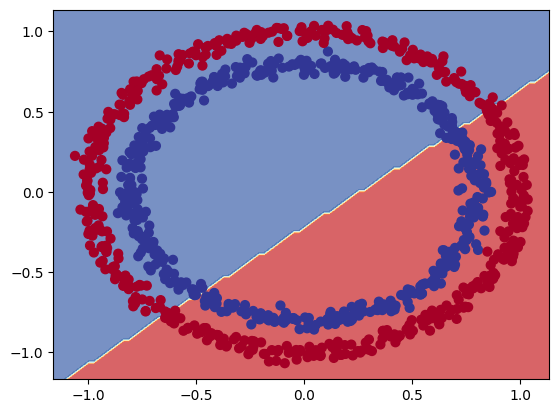

In [20]:
# Check out the predictions our model is making
plot_decision_boundary(model=model_3,
                       X=X,
                       y=y)

### The missing piece : Non Linearity

In [21]:
# Set tje random seed
tf.random.set_seed(42)

# 1. Create the model
model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.linear)
])

# 2. Compile the model
model_4.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(lr=0.001),
                metrics=["accuracy"])

# 3. Fit the model
history = model_4.fit(X, y, epochs=100)

Epoch 1/100
32/32 [==============================] - 1s 1ms/step - loss: 5.9863 - accuracy: 0.4790
Epoch 2/100
32/32 [==============================] - 0s 1ms/step - loss: 5.9594 - accuracy: 0.4790
Epoch 3/100
32/32 [==============================] - 0s 1ms/step - loss: 5.9421 - accuracy: 0.4800
Epoch 4/100
32/32 [==============================] - 0s 1ms/step - loss: 5.9070 - accuracy: 0.4790
Epoch 5/100
32/32 [==============================] - 0s 1ms/step - loss: 5.8338 - accuracy: 0.4830
Epoch 6/100
32/32 [==============================] - 0s 1ms/step - loss: 5.7786 - accuracy: 0.4850
Epoch 7/100
32/32 [==============================] - 0s 1ms/step - loss: 5.7740 - accuracy: 0.4840
Epoch 8/100
32/32 [==============================] - 0s 1ms/step - loss: 5.7626 - accuracy: 0.4830
Epoch 9/100
32/32 [==============================] - 0s 2ms/step - loss: 5.7297 - accuracy: 0.4850
Epoch 10/100
32/32 [==============================] - 0s 1ms/step - loss: 5.7291 - accuracy: 0.4840
Epoch 11/

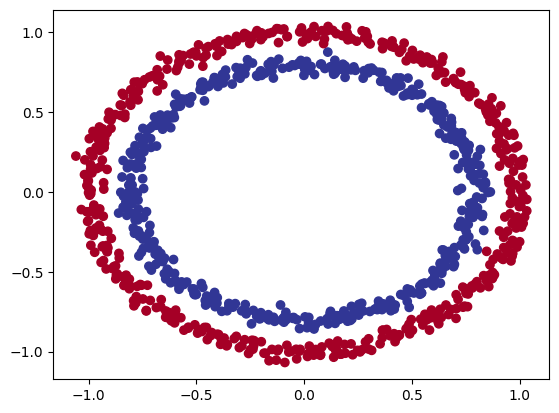

In [22]:
# Check out our data 
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

313/313 [==============================] - 0s 1ms/step
doing binary classification


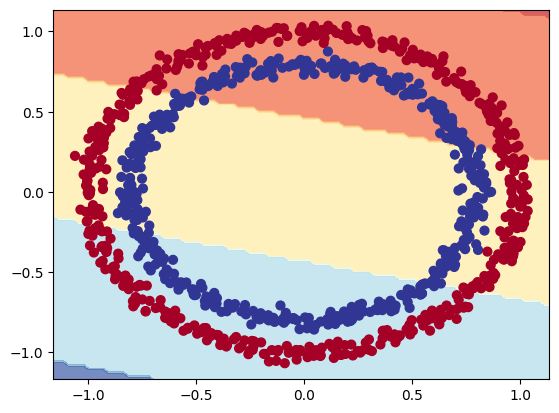

In [23]:
# Check the decision boundary for our latest model
plot_decision_boundary(model=model_4,
                       X=X,
                       y=y)

### let's try build our first neural network with a non-linear activation function

In [24]:
# Set random seed
tf.random.set_seed(42)

# 1. Create a model with a non-linear activation
model_5 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.relu)
])

# 2. Compile the model
model_5.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(lr=0.001),
                metrics=["accuracy"])

# 3. Fit the model
history = model_5.fit(X, y, epochs=100)

Epoch 1/100
32/32 [==============================] - 1s 2ms/step - loss: 4.8975 - accuracy: 0.4760
Epoch 2/100
32/32 [==============================] - 0s 1ms/step - loss: 4.7691 - accuracy: 0.4750
Epoch 3/100
32/32 [==============================] - 0s 1ms/step - loss: 4.7301 - accuracy: 0.4740
Epoch 4/100
32/32 [==============================] - 0s 1ms/step - loss: 4.6962 - accuracy: 0.4750
Epoch 5/100
32/32 [==============================] - 0s 1ms/step - loss: 4.6343 - accuracy: 0.4750
Epoch 6/100
32/32 [==============================] - 0s 1ms/step - loss: 4.5525 - accuracy: 0.4780
Epoch 7/100
32/32 [==============================] - 0s 1ms/step - loss: 4.5577 - accuracy: 0.4760
Epoch 8/100
32/32 [==============================] - 0s 1ms/step - loss: 4.5323 - accuracy: 0.4770
Epoch 9/100
32/32 [==============================] - 0s 1ms/step - loss: 4.5160 - accuracy: 0.4750
Epoch 10/100
32/32 [==============================] - 0s 1ms/step - loss: 4.5015 - accuracy: 0.4750
Epoch 11/

In [25]:
# Time to replicate the multi-layer neural network from TensorFLow playground

# Set the random seed
tf.random.set_seed(42)

# 1. Create the model
model_6 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_6.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(lr=0.001),
                metrics=["accuracy"])

# 3. Fit the model
history = model_6.fit(X, y, epochs=250)

Epoch 1/250
32/32 [==============================] - 1s 2ms/step - loss: 5.9285 - accuracy: 0.5000
Epoch 2/250
32/32 [==============================] - 0s 2ms/step - loss: 5.6151 - accuracy: 0.4750
Epoch 3/250
32/32 [==============================] - 0s 2ms/step - loss: 5.3433 - accuracy: 0.4520
Epoch 4/250
32/32 [==============================] - 0s 2ms/step - loss: 4.6859 - accuracy: 0.4730
Epoch 5/250
32/32 [==============================] - 0s 2ms/step - loss: 3.9346 - accuracy: 0.4860
Epoch 6/250
32/32 [==============================] - 0s 2ms/step - loss: 3.4979 - accuracy: 0.4860
Epoch 7/250
32/32 [==============================] - 0s 2ms/step - loss: 2.7287 - accuracy: 0.4900
Epoch 8/250
32/32 [==============================] - 0s 2ms/step - loss: 1.3412 - accuracy: 0.4910
Epoch 9/250
32/32 [==============================] - 0s 2ms/step - loss: 1.0317 - accuracy: 0.4920
Epoch 10/250
32/32 [==============================] - 0s 1ms/step - loss: 0.9771 - accuracy: 0.4910
Epoch 11/

In [26]:
# Evaluate the model
model_6.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.0631 - accuracy: 0.9920


[0.06314810365438461, 0.9919999837875366]

313/313 [==============================] - 0s 1ms/step
doing binary classification


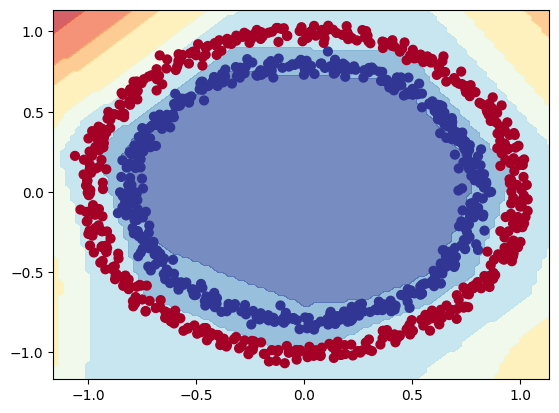

In [27]:
plot_decision_boundary(model=model_6,
                       X=X,
                       y=y)

In [28]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_7 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2. Compile the model
model_7.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=["accuracy"])

# 3. Fit the model
model_7.fit(X, y, epochs=100)

Epoch 1/100
32/32 [==============================] - 1s 2ms/step - loss: 0.6882 - accuracy: 0.5000
Epoch 2/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6842 - accuracy: 0.5000
Epoch 3/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6816 - accuracy: 0.5000
Epoch 4/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6802 - accuracy: 0.5000
Epoch 5/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6785 - accuracy: 0.5000
Epoch 6/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6770 - accuracy: 0.5000
Epoch 7/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6754 - accuracy: 0.5290
Epoch 8/100
32/32 [==============================] - 0s 3ms/step - loss: 0.6740 - accuracy: 0.5550
Epoch 9/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6725 - accuracy: 0.5850
Epoch 10/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6710 - accuracy: 0.5850
Epoch 11/

In [29]:
# 4. Evalute the model
model_7.evaluate(X, y)

32/32 [==============================] - 0s 2ms/step - loss: 0.2507 - accuracy: 0.9760


[0.25070205330848694, 0.9760000109672546]

313/313 [==============================] - 0s 1ms/step
doing binary classification


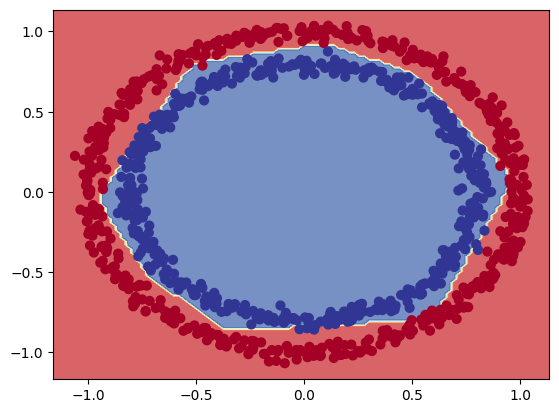

In [30]:
# Let's visualize our model_7
plot_decision_boundary(model_7, X, y)

In [31]:
# Split the dataset into train and test
X_train, y_train = X[:800], y[:800]
X_test, y_test = X[800:], y[800:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 2), (200, 2), (800,), (200,))

In [32]:
# Let's recreate a model to fit on the training data and evaluate on the testing data

# Set random seed
tf.random.set_seed(42)

# 1. Create the model (same as model_7)
model_8 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid") 
])

# 2. Compile the model
model_8.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics=["accuracy"])

# 3. Fit the model
history = model_8.fit(X_train, y_train, epochs=25)

Epoch 1/25
25/25 [==============================] - 1s 2ms/step - loss: 0.6921 - accuracy: 0.5188
Epoch 2/25
25/25 [==============================] - 0s 2ms/step - loss: 0.6885 - accuracy: 0.5275
Epoch 3/25
25/25 [==============================] - 0s 2ms/step - loss: 0.6844 - accuracy: 0.5175
Epoch 4/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6804 - accuracy: 0.5288
Epoch 5/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6736 - accuracy: 0.5512
Epoch 6/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6649 - accuracy: 0.5350
Epoch 7/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6473 - accuracy: 0.6325
Epoch 8/25
25/25 [==============================] - 0s 2ms/step - loss: 0.6351 - accuracy: 0.6375
Epoch 9/25
25/25 [==============================] - 0s 2ms/step - loss: 0.6089 - accuracy: 0.6525
Epoch 10/25
25/25 [==============================] - 0s 2ms/step - loss: 0.5791 - accuracy: 0.7075
Epoch 11/25
25/25 [

In [33]:
# 4. Evaluate the model
model_8.evaluate(X_test, y_test)

7/7 [==============================] - 0s 2ms/step - loss: 0.2618 - accuracy: 0.9300


[0.26177605986595154, 0.9300000071525574]

313/313 [==============================] - 1s 1ms/step
doing binary classification
313/313 [==============================] - 0s 1ms/step
doing binary classification


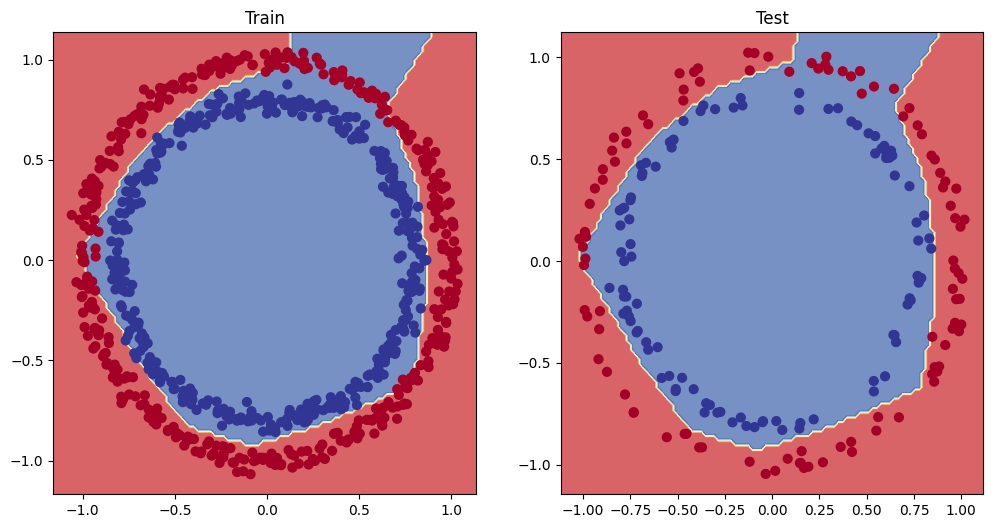

In [34]:
# Plot the decision boundaries for the training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_8, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_8, X_test, y_test)
plt.show()

### Plotting loss curve

In [35]:
# Convert the history object into a DataFrame
pd.DataFrame(history.history)

,loss,accuracy
0,0.692085,0.51875
1,0.688494,0.52750
2,0.684398,0.51750
3,0.680407,0.52875
4,0.673559,0.55125
5,0.664910,0.53500
6,0.647347,0.63250
7,0.635114,0.63750
8,0.608945,0.65250
9,0.579117,0.70750


Text(0.5, 1.0, 'Model_8 loss curves')

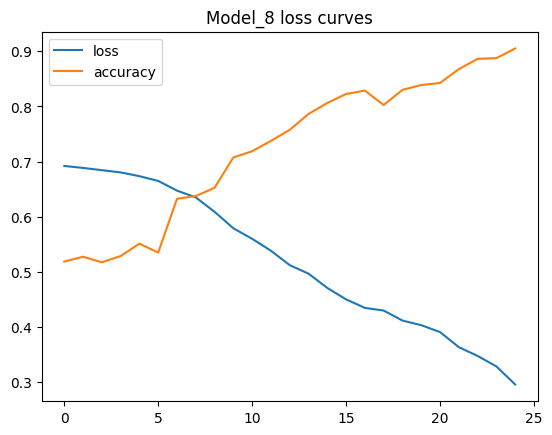

In [36]:
# Plot the loss curves
pd.DataFrame(history.history).plot()
plt.title("Model_8 loss curves")

## Finding the best learining rate

In [37]:
# Set random seed
tf.random.set_seed(42)

# 1. Create a model (same as model_8)
model_9 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2. Compile the model
model_9.compile(loss="binary_crossentropy",
                optimizer="Adam",
                metrics=["accuracy"])

# Create a learning rate callback
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch/20))

# 3. Fit the model (passing lr_scheduler callback)
history_9 = model_9.fit(X_train,
                        y_train,
                        epochs=100,
                        callbacks=[lr_scheduler])

Epoch 1/100
25/25 [==============================] - 1s 1ms/step - loss: 0.7097 - accuracy: 0.4950 - lr: 1.0000e-04
Epoch 2/100
25/25 [==============================] - 0s 1ms/step - loss: 0.7089 - accuracy: 0.4963 - lr: 1.1220e-04
Epoch 3/100
25/25 [==============================] - 0s 2ms/step - loss: 0.7081 - accuracy: 0.4963 - lr: 1.2589e-04
Epoch 4/100
25/25 [==============================] - 0s 1ms/step - loss: 0.7071 - accuracy: 0.4963 - lr: 1.4125e-04
Epoch 5/100
25/25 [==============================] - 0s 1ms/step - loss: 0.7062 - accuracy: 0.5000 - lr: 1.5849e-04
Epoch 6/100
25/25 [==============================] - 0s 1ms/step - loss: 0.7052 - accuracy: 0.4975 - lr: 1.7783e-04
Epoch 7/100
25/25 [==============================] - 0s 1ms/step - loss: 0.7042 - accuracy: 0.5013 - lr: 1.9953e-04
Epoch 8/100
25/25 [==============================] - 0s 1ms/step - loss: 0.7031 - accuracy: 0.5063 - lr: 2.2387e-04
Epoch 9/100
25/25 [==============================] - 0s 1ms/step - loss:

<Axes: xlabel='epochs'>

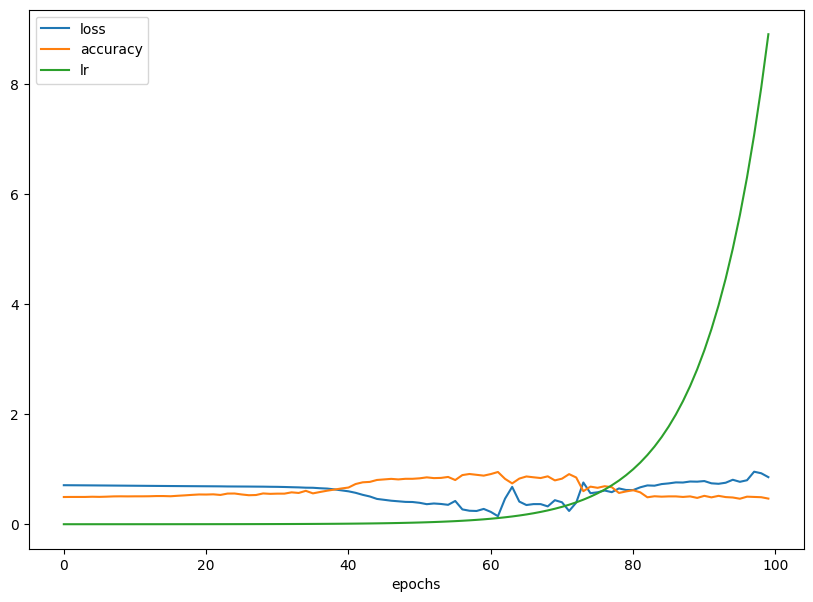

In [38]:
# Checout the history
pd.DataFrame(history_9.history).plot(figsize=(10, 7), xlabel="epochs")

Text(0.5, 1.0, 'Learning rate vs. Loss')

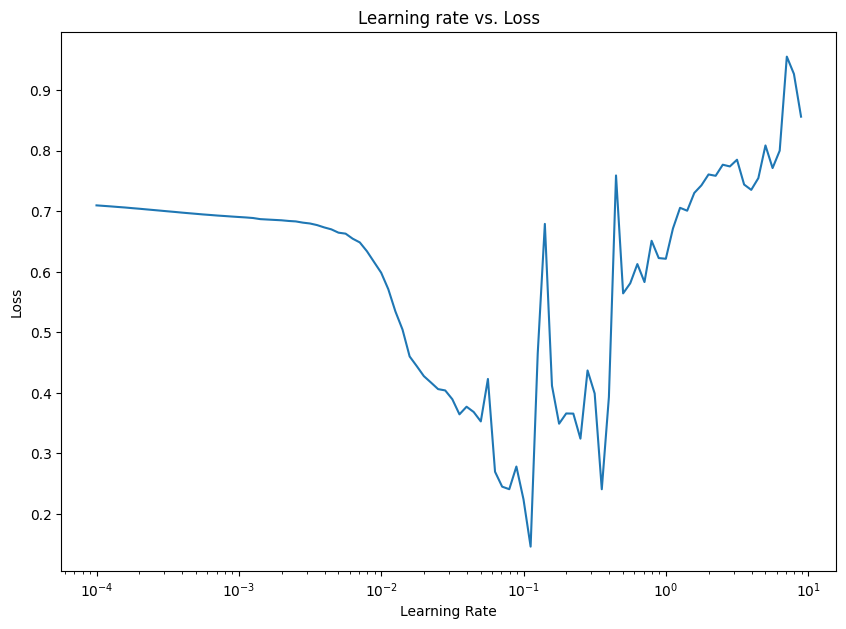

In [41]:
# Plot the learning rate versus the loss
lrs = 1e-4 * (10 ** (tf.range(100)/20))
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, history_9.history["loss"])
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning rate vs. Loss")